# Generic PWR Dry Cask — Assembly-Level Pin Geometry Model

This notebook models a generic PWR dry cask storage container in OpenMC.
The geometry is loosely based on publicly available specifications for multi-purpose
canisters (MPC) such as the Holtec HI-STORM 100 system.

## Geometry overview
- **Fuel region**: 4x4 array of PWR fuel assemblies. Each assembly is modeled as an
  explicit 17x17 pin lattice with discrete fuel pellet, He gap annulus, Zircaloy-4
  clad, and interstitial helium. Guide/instrument tubes are
  modeled as helium-filled Zircaloy tubes.
- **Canister**: 5/8" stainless steel 304 inner canister, helium backfill.
- **Overpack**: Thick-walled carbon steel outer overpack with concrete fill.

## Key dimensions (approximate, generic)
| Component | Dimension |
|---|---|
| Fuel active length | 365.8 cm |
| Pin pitch | 1.26 cm |
| Fuel pellet radius | 0.4096 cm |
| Clad outer radius | 0.4750 cm |
| Assembly pitch | 21.50 cm (17x17) |
| MPC inner diameter | 170.2 cm |
| Concrete shield thickness | 60 cm |
| Total cask outer diameter | ~307 cm |

In [ ]:
# author: Eric Yokie
# openMC 0.15.2

import os
import numpy as np
import matplotlib.pyplot as plt
import openmc

# replace with your cross section library location
CROSS_SECTIONS = '/home/eric/openmc/nuclear_data/endf-b8.0-hdf5/endfb-viii.0-hdf5/cross_sections.xml'

openmc.config['cross_sections'] = CROSS_SECTIONS
os.environ['OPENMC_CROSS_SECTIONS'] = CROSS_SECTIONS


In [43]:
spent_fuel = openmc.Material(name='spent_uo2')
spent_fuel.set_density('g/cm3', 10.4)
spent_fuel.add_nuclide('U234',  1.80e-4, 'wo')
spent_fuel.add_nuclide('U235',  8.10e-3, 'wo')  # ~0.81 wt% after burnup
spent_fuel.add_nuclide('U236',  5.20e-3, 'wo')
spent_fuel.add_nuclide('U238',  9.20e-1, 'wo')
spent_fuel.add_nuclide('Pu238', 2.10e-4, 'wo')
spent_fuel.add_nuclide('Pu239', 5.90e-3, 'wo')
spent_fuel.add_nuclide('Pu240', 2.60e-3, 'wo')
spent_fuel.add_nuclide('Pu241', 1.00e-3, 'wo')
spent_fuel.add_nuclide('Pu242', 5.50e-4, 'wo')
spent_fuel.add_nuclide('Am241', 4.20e-4, 'wo')
spent_fuel.add_nuclide('Cs137', 2.80e-3, 'wo')  # 662 keV gamma source
spent_fuel.add_nuclide('Eu154', 1.80e-4, 'wo')
spent_fuel.add_nuclide('Sm149', 4.00e-5, 'wo')  # strong absorber
spent_fuel.add_nuclide('Nd143', 8.00e-4, 'wo')
spent_fuel.add_nuclide('Nd145', 6.20e-4, 'wo')
spent_fuel.add_nuclide('Rh103', 3.20e-4, 'wo')
spent_fuel.add_nuclide('Ru101', 4.80e-4, 'wo')
spent_fuel.add_nuclide('Mo95',  5.80e-4, 'wo')
spent_fuel.add_nuclide('Tc99',  7.20e-4, 'wo')
spent_fuel.add_nuclide('Zr93',  5.50e-4, 'wo')
spent_fuel.add_element('O',     1.34e-1, 'wo')
spent_fuel.add_nuclide('Sr90',  1.50e-3, 'wo')
spent_fuel.add_nuclide('Kr85',  1.20e-4, 'wo')

zircaloy = openmc.Material(name='zircaloy4')
zircaloy.set_density('g/cm3', 6.56)
zircaloy.add_element('Zr', 0.9825, 'wo')
zircaloy.add_element('Sn', 0.0145, 'wo')
zircaloy.add_element('Fe', 0.0021, 'wo')
zircaloy.add_element('Cr', 0.0010, 'wo')

helium = openmc.Material(name='helium')
helium.set_density('g/cm3', 1.664e-4)
helium.add_element('He', 1.0, 'ao')

ss304 = openmc.Material(name='ss304')
ss304.set_density('g/cm3', 8.03)
ss304.add_element('Fe', 0.6892, 'wo')
ss304.add_element('Cr', 0.19,   'wo')
ss304.add_element('Ni', 0.10,   'wo')
ss304.add_element('Mn', 0.02,   'wo')
ss304.add_element('Si', 0.01,   'wo')
ss304.add_element('C',  0.0008, 'wo')

carbon_steel = openmc.Material(name='carbon_steel')
carbon_steel.set_density('g/cm3', 7.85)
carbon_steel.add_element('Fe', 0.9865, 'wo')
carbon_steel.add_element('C',  0.0025, 'wo')
carbon_steel.add_element('Mn', 0.0075, 'wo')
carbon_steel.add_element('Si', 0.0035, 'wo')

concrete = openmc.Material(name='concrete')
concrete.set_density('g/cm3', 2.3)
concrete.add_element('H',  0.0101, 'wo')
concrete.add_element('O',  0.5290, 'wo')
concrete.add_element('Na', 0.0153, 'wo')
concrete.add_element('Mg', 0.0021, 'wo')
concrete.add_element('Al', 0.0469, 'wo')
concrete.add_element('Si', 0.3155, 'wo')
concrete.add_element('K',  0.0192, 'wo')
concrete.add_element('Ca', 0.0826, 'wo')
concrete.add_element('Fe', 0.0124, 'wo')

# Pin dimensions (cm) — standard Westinghouse 17x17
pin_pitch  = 1.26
r_fuel     = 0.4096
r_clad_i   = 0.4179
r_clad_o   = 0.4750
r_gt_i     = 0.5715
r_gt_o     = 0.6120
assy_pitch = 21.50

# Guide tube positions (row, col), 0-indexed — standard Westinghouse 17x17 pattern
GT_POSITIONS = [
    (2,5),(2,8),(2,11),
    (3,3),(3,13),
    (5,2),(5,5),(5,8),(5,11),(5,14),
    (8,2),(8,5),(8,8),(8,11),(8,14),
    (11,2),(11,5),(11,8),(11,11),(11,14),
    (13,3),(13,13),
    (14,5),(14,8),(14,11),
]


## Cell 3 — Geometry: Cask cross-section with explicit pin lattice

We model a **2D radial slice** (infinite in z with reflective top/bottom planes)
through the mid-plane of the cask. Each of the 16 assembly slots in the 4x4 basket
now contains a full 17x17 pin lattice with explicit fuel pin, He gap, clad, and
interstitial helium geometry.

### Universe hierarchy

- **root_universe**
  - **basket_universe** — 4×4 RectLattice, pitch = 21.5 cm
    - **assembly_universe** — one shared universe per slot
      - **pin_lattice** — 17×17 RectLattice, pitch = 1.26 cm
        - **fuel_pin_universe** (264 per assembly) — fuel pellet (spent_uo2, r=0.4096 cm) -> He gap (r=0.4096–0.4179 cm) -> Zircaloy-4 clad (r=0.4179–0.4750 cm) -> He interstitial
        - **guide_tube_universe** (25 per assembly) — He fill (r<0.5715 cm) -> Zircaloy-4 wall (r=0.5715–0.6120 cm) -> He outer

### Layout (radial, inside-out)
  - Basket region (fuel+SS): 0 – 60.0 cm
  - He gap: 60.0 – 83.5 cm
  - MPC SS wall: 83.5 – 84.77 cm
  - Inner steel overpack: 84.77 – 89.77 cm
  - Concrete: 89.77 – 149.77 cm
  - Outer steel shell: 149.77 – 152.31 cm
  - Scoring air: 152.31 – 200 cm


In [ ]:
# Cask radial dimensions (cm)
r_basket, r_he_gap      = 60.0,  83.5
r_mpc_wall, r_inner_steel = 84.77, 89.77
r_concrete, r_outer_steel = 149.77, 152.31
r_scoring = 200.0
hz = 400.0

s_basket      = openmc.ZCylinder(r=r_basket,      name='basket_outer')
s_he_gap      = openmc.ZCylinder(r=r_he_gap,      name='he_gap_outer')
s_mpc_wall    = openmc.ZCylinder(r=r_mpc_wall,    name='mpc_wall_outer')
s_inner_steel = openmc.ZCylinder(r=r_inner_steel, name='inner_steel_outer')
s_concrete    = openmc.ZCylinder(r=r_concrete,    name='concrete_outer')
s_outer_steel = openmc.ZCylinder(r=r_outer_steel, name='outer_steel_outer')
s_scoring     = openmc.ZCylinder(r=r_scoring,     name='scoring_boundary', boundary_type='vacuum')
top    = openmc.ZPlane(z0= hz, boundary_type='reflective')
bottom = openmc.ZPlane(z0=-hz, boundary_type='reflective')


def make_fuel_pin_universe():
    """pellet | He gap | Zr clad | He interstitial"""
    s_p = openmc.ZCylinder(r=r_fuel)
    s_g = openmc.ZCylinder(r=r_clad_i)
    s_c = openmc.ZCylinder(r=r_clad_o)
    return openmc.Universe(cells=[
        openmc.Cell(fill=spent_fuel, region=-s_p),
        openmc.Cell(fill=helium,     region=+s_p & -s_g),
        openmc.Cell(fill=zircaloy,   region=+s_g & -s_c),
        openmc.Cell(fill=helium,     region=+s_c),
    ])


def make_guide_tube_universe():
    """He fill | Zr wall | He outside — all channels He-filled in dry storage"""
    s_i = openmc.ZCylinder(r=r_gt_i)
    s_o = openmc.ZCylinder(r=r_gt_o)
    return openmc.Universe(cells=[
        openmc.Cell(fill=helium,   region=-s_i),
        openmc.Cell(fill=zircaloy, region=+s_i & -s_o),
        openmc.Cell(fill=helium,   region=+s_o),
    ])


def make_assembly_universe():
    """17x17 pin lattice with SS304 assembly wrapper"""
    fp = make_fuel_pin_universe()
    gt = make_guide_tube_universe()

    grid = [[fp] * 17 for _ in range(17)]
    for r, c in GT_POSITIONS:
        grid[r][c] = gt

    lat = openmc.RectLattice(name='pin_lattice_17x17')
    lat.pitch      = (pin_pitch, pin_pitch)
    lat.lower_left = (-17/2 * pin_pitch, -17/2 * pin_pitch)
    lat.universes  = grid

    half = 17/2 * pin_pitch
    lat_region = (+openmc.XPlane(x0=-half) & -openmc.XPlane(x0=half) &
                  +openmc.YPlane(y0=-half) & -openmc.YPlane(y0=half))
    wrap_region = (+openmc.XPlane(x0=-assy_pitch/2) & -openmc.XPlane(x0=assy_pitch/2) &
                   +openmc.YPlane(y0=-assy_pitch/2) & -openmc.YPlane(y0=assy_pitch/2)
                   & ~lat_region)
    return openmc.Universe(cells=[
        openmc.Cell(fill=lat,   region=lat_region),
        openmc.Cell(fill=ss304, region=wrap_region),
    ])


def make_basket_universe():
    """4x4 lattice of assemblies; SS304 fills outside the lattice box"""
    assy = make_assembly_universe()

    lat = openmc.RectLattice(name='basket_lattice_4x4')
    lat.pitch      = (assy_pitch, assy_pitch)
    lat.lower_left = (-2*assy_pitch, -2*assy_pitch)
    lat.universes  = [[assy]*4 for _ in range(4)]

    box = (+openmc.XPlane(x0=-2*assy_pitch) & -openmc.XPlane(x0=2*assy_pitch) &
           +openmc.YPlane(y0=-2*assy_pitch) & -openmc.YPlane(y0=2*assy_pitch))
    return openmc.Universe(cells=[
        openmc.Cell(fill=lat,   region=box),
        openmc.Cell(fill=ss304, region=-s_basket & ~box),
    ])


root = openmc.Universe(cells=[
    openmc.Cell(fill=make_basket_universe(), region=-s_basket      & +bottom & -top),
    openmc.Cell(fill=helium,                region=+s_basket      & -s_he_gap      & +bottom & -top),
    openmc.Cell(fill=ss304,                 region=+s_he_gap      & -s_mpc_wall    & +bottom & -top),
    openmc.Cell(fill=carbon_steel,          region=+s_mpc_wall    & -s_inner_steel & +bottom & -top),
    openmc.Cell(fill=concrete,              region=+s_inner_steel & -s_concrete    & +bottom & -top),
    openmc.Cell(fill=carbon_steel,          region=+s_concrete    & -s_outer_steel & +bottom & -top),
    openmc.Cell(fill=None,                  region=+s_outer_steel & -s_scoring     & +bottom & -top),
])
geometry = openmc.Geometry(root)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

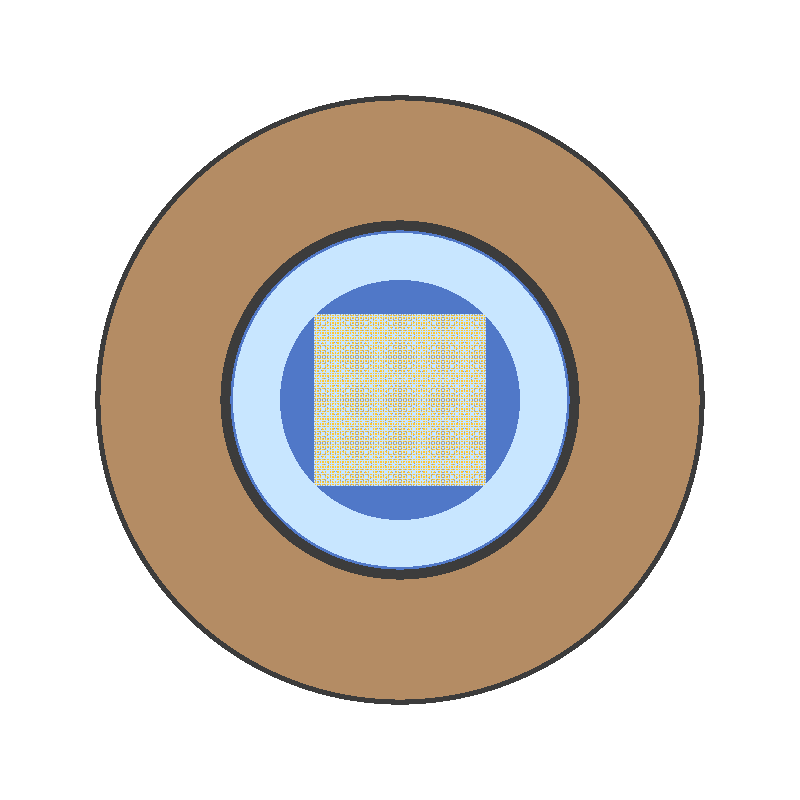

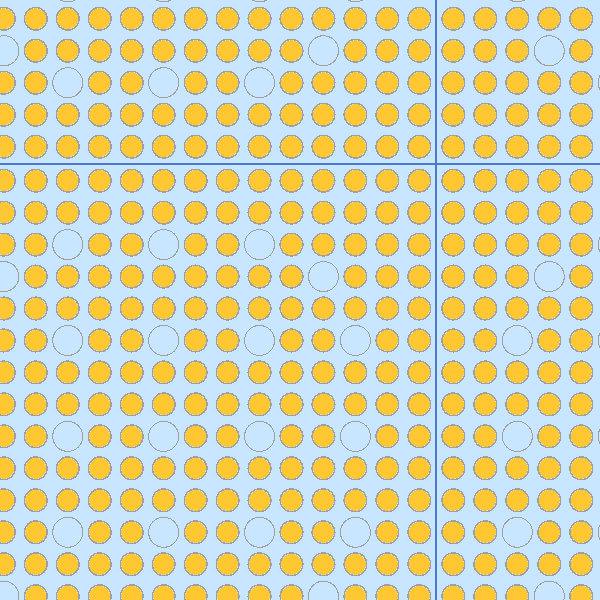

In [45]:
materials = openmc.Materials([spent_fuel, zircaloy, helium, ss304, carbon_steel, concrete])
materials.export_to_xml()
geometry.export_to_xml()

COLORS = {
    spent_fuel:   (255, 200,  50),
    zircaloy:     (160, 160, 160),
    helium:       (200, 230, 255),
    ss304:        ( 80, 120, 200),
    carbon_steel: ( 60,  60,  60),
    concrete:     (180, 140, 100),
}

plot_cask = openmc.Plot(name='full_cask')
plot_cask.basis, plot_cask.origin = 'xy', (0, 0, 0)
plot_cask.width, plot_cask.pixels = (2*r_scoring, 2*r_scoring), (800, 800)
plot_cask.color_by, plot_cask.colors = 'material', COLORS

plot_assy = openmc.Plot(name='assembly_zoom')
plot_assy.basis, plot_assy.origin = 'xy', (assy_pitch*0.75, assy_pitch*0.75, 0)
plot_assy.width, plot_assy.pixels = (assy_pitch*1.1, assy_pitch*1.1), (600, 600)
plot_assy.color_by, plot_assy.colors = 'material', COLORS

openmc.Plots([plot_cask, plot_assy]).export_to_xml()
openmc.plot_geometry()

from IPython.display import Image, display
display(Image('plot_1.png'))
display(Image('plot_2.png'))


## Cell 5 — Source Definition

Spent fuel emits:
1. **Spontaneous fission neutrons** — dominated by Cm-244 at 45 GWd/tHM, ~10yr cooling.
   We use a Watt fission spectrum characteristic of Cf-252 as a conservative approximation.
2. **Decay gamma photons** — dominated by Cs-137 (662 keV), Eu-154 (1.27 MeV), Co-60 (1.17/1.33 MeV).
   We define a discrete-line gamma source weighted by relative activity.

Both sources are uniformly distributed over the fuel basket volume (cylinder of radius r_basket).

In [46]:
spatial_dist = openmc.stats.CylindricalIndependent(
    r=openmc.stats.Uniform(0, r_basket),
    phi=openmc.stats.Uniform(0, 2*np.pi),
    z=openmc.stats.Uniform(-hz*0.5, hz*0.5),
    origin=(0.0, 0.0, 0.0)
)

neutron_source = openmc.IndependentSource(
    space=spatial_dist,
    angle=openmc.stats.Isotropic(),
    energy=openmc.stats.Watt(a=0.977e6, b=2.996e-6),  # Cf-252, conservative for Cm-244 SF
    particle='neutron',
    strength=1.0
)

gamma_energies = [0.662e6, 1.274e6, 0.123e6, 1.173e6, 1.333e6, 0.898e6, 0.722e6, 0.606e6]
gamma_weights  = np.array([1.000, 0.120, 0.090, 0.050, 0.050, 0.040, 0.030, 0.025])
gamma_weights /= gamma_weights.sum()

gamma_source = openmc.IndependentSource(
    space=spatial_dist,
    angle=openmc.stats.Isotropic(),
    energy=openmc.stats.Discrete(gamma_energies, gamma_weights),
    particle='photon',
    strength=10.0
)


## Cell 6 — Tallies

We use three tallies:

1. **2D mesh flux tally** — neutron + photon flux on an XY mesh across the full cask cross-section.
   Used to produce dose-rate color maps.

2. **Radial flux tally** — flux as a function of radius using cylindrical mesh.
   Used for the 1D dose-rate vs. distance plot.

3. **Surface current tally** — particles crossing the outer steel surface,
   for a direct surface dose estimate.

Dose conversion factors come from ANSI/ANS-6.1.1-1977 (neutron) and ICRP-21 (photon),
implemented as energy function filters.

In [55]:
neutron_dose_energies = np.array([
    1e-9, 1e-8, 2.53e-8, 1e-7, 2e-7, 5e-7, 1e-6, 2e-6, 5e-6,
    1e-5, 2e-5, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3,
    1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 3e-1, 5e-1, 7e-1,
    1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10., 12., 14., 16., 18., 20.
]) * 1e6

photon_dose_energies = np.array([
    0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10,
    0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00, 1.50, 2.00,
    3.00, 4.00, 5.00, 6.00, 8.00, 10.0
]) * 1e6

n_energy_bins = np.concatenate([[1e-5], neutron_dose_energies[neutron_dose_energies < 2.01e7]])
p_energy_bins = np.concatenate([[1e3],  photon_dose_energies])

nf = openmc.ParticleFilter('neutron')
pf = openmc.ParticleFilter('photon')
nef = openmc.EnergyFilter(n_energy_bins)
pef = openmc.EnergyFilter(p_energy_bins)

mesh_xy = openmc.RegularMesh(name='xy_mesh')
mesh_xy.dimension   = [200, 200, 1]
mesh_xy.lower_left  = (-r_scoring, -r_scoring, -1.0)
mesh_xy.upper_right = ( r_scoring,  r_scoring,  1.0)
mf_xy = openmc.MeshFilter(mesh_xy)

mesh_cyl = openmc.CylindricalMesh(
    r_grid=np.linspace(0, r_scoring, 201),
    z_grid=[-1.0, 1.0],
    phi_grid=[0, 2*np.pi],
    name='cyl_mesh'
)
mf_cyl = openmc.MeshFilter(mesh_cyl)
sf = openmc.SurfaceFilter(s_outer_steel)

def tally(name, filters, score):
    t = openmc.Tally(name=name)
    t.filters, t.scores = filters, [score]
    return t

tallies = openmc.Tallies([
    tally('neutron_flux_mesh',    [mf_xy,  nef, nf], 'flux'),
    tally('photon_flux_mesh',     [mf_xy,  pef, pf], 'flux'),
    tally('neutron_flux_radial',  [mf_cyl, nf],      'flux'),
    tally('photon_flux_radial',   [mf_cyl, pf],      'flux'),
    tally('surface_current_neutron', [sf,  nf],      'current'),
    tally('surface_current_photon',  [sf,  pf],      'current'),
])
tallies.export_to_xml()


## Cell 7 — Settings and Run

In [48]:
settings = openmc.Settings()
settings.run_mode        = 'fixed source'
settings.source          = [neutron_source, gamma_source]
settings.particles       = 1_000_000
settings.batches         = 20
settings.photon_transport = True
settings.output          = {'tallies': False, 'summary': True}


In [49]:
import glob

project_dir = '/home/eric/Documents/openMC_models/Dry_Cask'
os.chdir(project_dir)

for f in glob.glob('*.xml'):
    os.remove(f)
for f in glob.glob('*.h5'):
    os.remove(f)

materials.export_to_xml()
geometry.export_to_xml()
settings.export_to_xml()
tallies.export_to_xml()

openmc.run()


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

## Cell 8 — Results: Dose Rate Maps and Radial Profile

We convert flux tallies to dose rates using the ANSI/ANS-6.1.1 flux-to-dose factors.
The conversion is:

$$\dot{H}^*(10) = \sum_g \phi_g \cdot h_g$$

where $\phi_g$ is the flux in energy group $g$ (n/cm²/s per source particle) and
$h_g$ is the dose coefficient in pSv·cm². Results are in arbitrary units proportional
to actual dose rate — normalize against a known source strength to get absolute mSv/hr.

In [50]:
sp = openmc.StatePoint(sorted(glob.glob('statepoint.*.h5'))[-1])

n_flux_mesh = sp.get_tally(name='neutron_flux_mesh').get_slice(scores=['flux']).mean.reshape(200, 200, -1).sum(axis=2)
p_flux_mesh = sp.get_tally(name='photon_flux_mesh').get_slice(scores=['flux']).mean.reshape(200, 200, -1).sum(axis=2)

n_flux_rad  = sp.get_tally(name='neutron_flux_radial').get_slice(scores=['flux']).mean.ravel()
p_flux_rad  = sp.get_tally(name='photon_flux_radial').get_slice(scores=['flux']).mean.ravel()
# n_flux_rad  = np.where(sp.get_tally(name='neutron_flux_radial').get_slice(scores=['flux']).std_dev.ravel() / n_flux_rad < 0.75, n_flux_rad, np.nan)
# p_flux_rad  = np.where(sp.get_tally(name='photon_flux_radial').get_slice(scores=['flux']).std_dev.ravel() / p_flux_rad < 1, p_flux_rad, np.nan)

r_centers   = 0.5*(mesh_cyl.r_grid[:-1] + mesh_cyl.r_grid[1:])


Key features of the radial flux profile, as seen in the plot below:

- **Neutron flux peak at ~40–50 cm** — flux builds toward the basket periphery rather than peaking at the center, reflecting the geometry of the 4x4 assembly arrangement and scattering within the SS304 basket structure.
- **Sharp drop at ~60 cm** — abrupt transition from the fuel/basket region into the helium gap removes the scattering medium, causing a clean flux depression.
- **Backscatter bump at ~84–89 cm** — both neutron and photon flux recover slightly at the MPC stainless steel wall, a classic backscatter signature from a high-density material interface.
- **Effective attenuation beyond the cask wall (~152 cm)** — flux is negligible beyond the outer steel shell, confirming that the concrete and steel overpack are performing as intended.

The photon flux is lower than the neutron flux throughout the basket region despite the 10× source weighting applied in the simulation, reflecting the greater mean free path of photons relative to fast neutrons in the fuel/basket material mix.

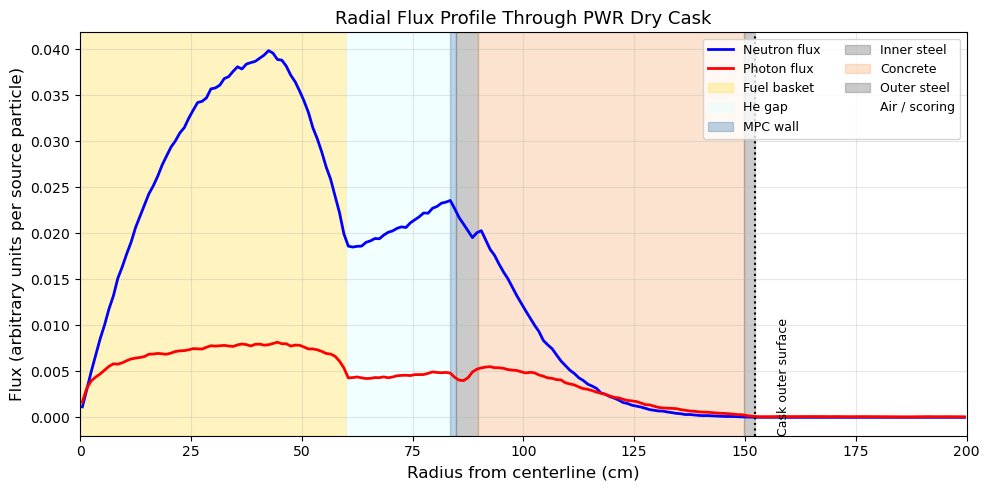

Saved radial_flux_profile.png


In [ ]:
# No energy-dependent dose for radial tally — use total flux as proxy
# (energy-integrated, so dose conversion would need a separate energy filter)
r_centers = 0.5 * (mesh_cyl.r_grid[:-1] + mesh_cyl.r_grid[1:])

fig, ax = plt.subplots(figsize=(10, 5))

# ax.semilogy(r_centers, n_flux_rad, 'b-', lw=2, label='Neutron flux')
# ax.semilogy(r_centers, p_flux_rad, 'r-', lw=2, label='Photon flux')

ax.plot(r_centers, n_flux_rad, 'b-', lw=2, label='Neutron flux')
ax.plot(r_centers, p_flux_rad, 'r-', lw=2, label='Photon flux')

# Shade material regions
region_bounds = [
    (0,             r_basket,      'gold',       'Fuel basket',    0.25),
    (r_basket,      r_he_gap,      'lightcyan',  'He gap',         0.40),
    (r_he_gap,      r_mpc_wall,    'steelblue',  'MPC wall',       0.35),
    (r_mpc_wall,    r_inner_steel, 'dimgray',    'Inner steel',    0.35),
    (r_inner_steel, r_concrete,    'sandybrown', 'Concrete',       0.30),
    (r_concrete,    r_outer_steel, 'dimgray',    'Outer steel',    0.35),
    (r_outer_steel, r_scoring,     'white',      'Air / scoring',  0.15),
]
for r_lo, r_hi, color, label, alpha in region_bounds:
    ax.axvspan(r_lo, r_hi, alpha=alpha, color=color, label=label)

ax.set_xlabel('Radius from centerline (cm)', fontsize=12)
ax.set_ylabel('Flux (A.U. per source particle)', fontsize=12)
ax.set_title('Radial Flux Profile Through PWR Dry Cask', fontsize=13)
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_xlim(0, r_scoring)
ax.grid(True, which='both', alpha=0.3)

# Annotate the outer surface
ax.axvline(r_outer_steel, color='k', linestyle=':', lw=1.5, label='Outer surface')
ax.annotate('Cask outer surface', xy=(r_outer_steel, ax.get_ylim()[0]),
            xytext=(r_outer_steel+5, ax.get_ylim()[0]),
            fontsize=9, rotation=90, va='bottom')

plt.tight_layout()
plt.savefig('radial_flux_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved radial_flux_profile.png')

## Dose Rate Maps (XY Cross-Section)

2D dose rate maps (below) computed from the XY mesh flux tallies using ANSI/ANS-6.1.1 (neutron) and ICRP-116 (photon) flux-to-dose conversion factors. Bins with relative error > 50% are masked. Remaining low-statistics bins in the outer air region are retained and rendered at the bottom of the colorscale rather than clipped, preserving the physical attenuation gradient through the concrete overpack.

- **Neutron dose** peaks in the fuel basket and attenuates sharply through the concrete overpack. The smooth radial gradient reflects the cylindrical symmetry of the source and the effectiveness of the steel/concrete shielding.
- **Photon dose** is lower in magnitude but more penetrating. The gradient is shallower and extends further into the overpack region.
- **Total dose** is neutron-dominated inside the basket but photons carry a larger share of the dose toward the cask surface, consistent with the surface current results.

Dashed circles mark material boundaries.

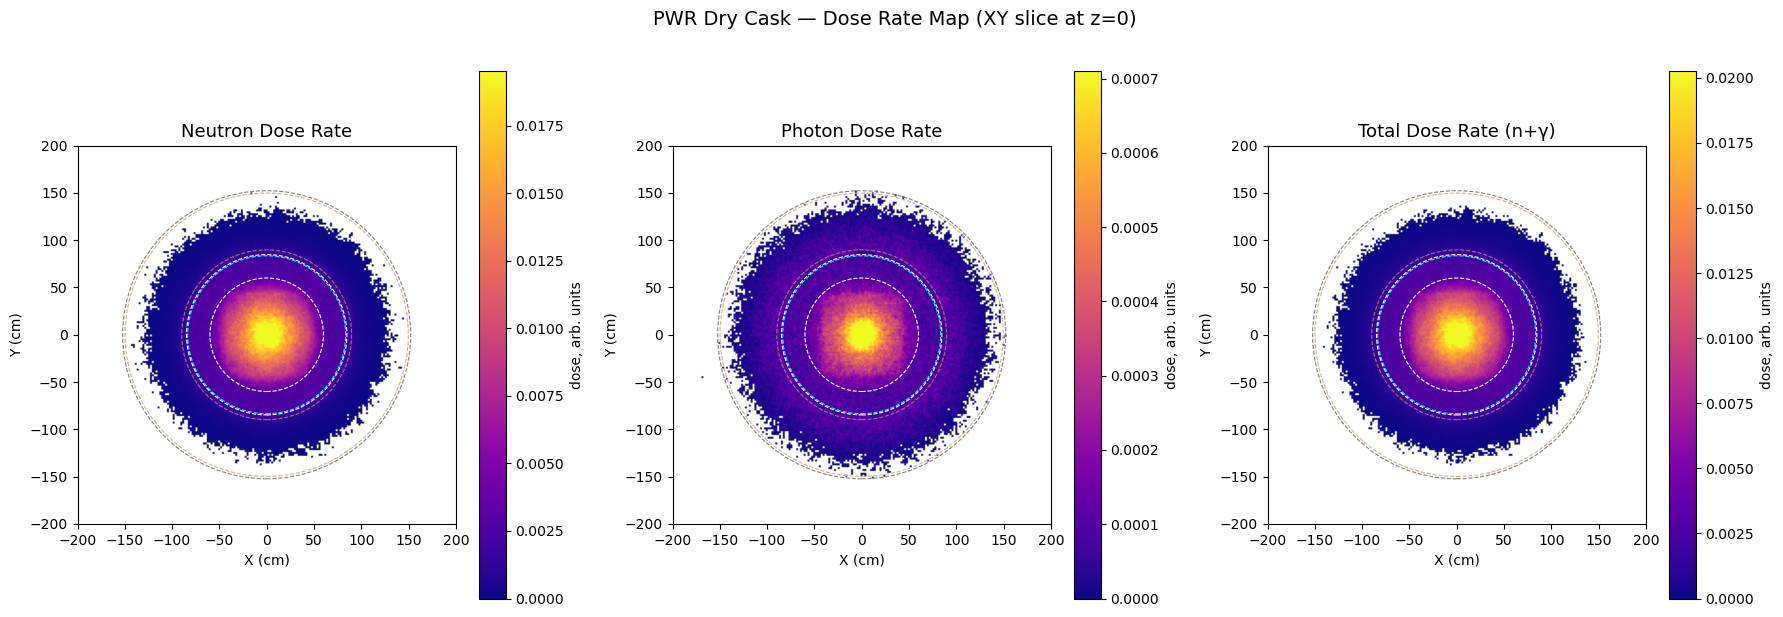

In [91]:
neutron_dose_coeff = np.array([
    3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76,
    3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76, 3.76,
    4.80, 5.27, 7.72, 1.24e1, 2.40e1, 2.97e1, 3.54e1, 3.61e1,
    3.72e1, 3.72e1, 3.57e1, 3.16e1, 2.90e1, 2.72e1, 2.60e1, 2.51e1,
    2.45e1, 2.42e1, 2.39e1, 2.38e1, 2.39e1, 2.41e1, 2.44e1, 2.49e1
])
photon_dose_coeff = np.array([
    0.0288, 0.0560, 0.0812, 0.152, 0.202, 0.240, 0.269, 0.295, 0.323, 0.380,
    0.534, 0.692, 1.00, 1.32, 1.63, 1.91, 2.44, 2.94, 3.97, 4.93,
    6.76, 8.50, 10.1, 11.7, 14.9, 17.7
])

def flux_to_dose(flux_data, dose_energies, dose_coeffs, energy_filter):
    h = np.interp(energy_filter.bins[:, 0], dose_energies, dose_coeffs, left=0, right=0)
    return np.sum(flux_data * h, axis=-1)

def rel_err_mask(flux_raw, std_raw, threshold=0.5):
    total = flux_raw.sum(axis=2)
    rel   = np.divide(np.sqrt((std_raw**2).sum(axis=2)), total,
                      out=np.ones_like(total), where=total > 0)
    return rel < threshold

sp = openmc.StatePoint('statepoint.20.h5')
t_n_mesh = sp.get_tally(name='neutron_flux_mesh')
t_p_mesh = sp.get_tally(name='photon_flux_mesh')

n_ef, p_ef     = t_n_mesh.find_filter(openmc.EnergyFilter), t_p_mesh.find_filter(openmc.EnergyFilter)
n_slice        = t_n_mesh.get_slice(scores=['flux'])
p_slice        = t_p_mesh.get_slice(scores=['flux'])
n_flux_raw     = n_slice.mean.reshape(200, 200, n_ef.num_bins)
p_flux_raw     = p_slice.mean.reshape(200, 200, p_ef.num_bins)
n_std          = n_slice.std_dev.reshape(200, 200, n_ef.num_bins)
p_std          = p_slice.std_dev.reshape(200, 200, p_ef.num_bins)

n_dose_map     = np.where(rel_err_mask(n_flux_raw, n_std), flux_to_dose(n_flux_raw, neutron_dose_energies, neutron_dose_coeff, n_ef), np.nan)
p_dose_map     = np.where(rel_err_mask(p_flux_raw, p_std), flux_to_dose(p_flux_raw, photon_dose_energies,  photon_dose_coeff,  p_ef), np.nan)
total_dose_map = np.where(np.isnan(n_dose_map) | np.isnan(p_dose_map), np.nan, n_dose_map + p_dose_map)

extent = [-r_scoring, r_scoring, -r_scoring, r_scoring]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (data, title, cmap) in zip(axes, [
    (n_dose_map,     'Neutron Dose Rate',     'plasma'),
    (p_dose_map,     'Photon Dose Rate',      'plasma'),
    (total_dose_map, 'Total Dose Rate (n+γ)', 'plasma'),
]):
    im = ax.imshow(np.where(data > 0, data, np.nan).T,
                   origin='lower', extent=extent, cmap=cmap, aspect='equal',
                   vmin=0, vmax=np.nanpercentile(data, 99))
    plt.colorbar(im, ax=ax, label='dose, arb. units')
    for r, color in [
        (r_basket,      'white'), (r_he_gap,       'cyan'),
        (r_mpc_wall,    'white'), (r_inner_steel,  'gray'),
        (r_concrete,    'tan'),   (r_outer_steel,  'gray'),
    ]:
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color=color, linewidth=0.8, linestyle='--'))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')

plt.suptitle('PWR Dry Cask — Dose Rate Map (XY slice at z=0)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('dose_map_xy.png', dpi=150, bbox_inches='tight')
plt.show()